# 02 — NSDCC Cleaning
**Phase:** Data Preparation

**What this notebook does:**
- Loads 5 NSDCC raw files: ART, HTS, HTS_Positive, VLT, IIT
- Strips `' County'` suffix, standardises county names, renames MOH columns
- Converts to numeric, imputes missing values (county mean → column median)
- Creates before/after missing-value heatmaps for every dataset
- Validates 47 counties and 0 duplicates per file
- Saves 5 clean CSVs to `data/processed/`

**Outputs:**
- `adult_on_art_clean.csv`
- `hts_clean.csv`
- `hts_positive_clean.csv`
- `vlt_clean.csv`
- `iit_clean.csv`



## ── NSDCC SECTION ──


### Cell 1 — Imports

In [92]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# ── All paths, column names and rename maps from constants.py
from constants import (
    ADULT_ART_FILE, HTS_FILE, HTS_POSITIVE_FILE, VLT_FILE, IIT_FILE,
    ART_CLEAN, HTS_CLEAN, HTS_POS_CLEAN, VLT_CLEAN, IIT_CLEAN, PROCESSED_DIR,
    ART_COUNTY_COL, ART_PERIOD_COL, ART_COUNTY_SUFFIX,
    HTS_COUNTY_COL, HTS_PERIOD_COL, HTS_COUNTY_SUFFIX,
    HTS_POS_COUNTY_COL, HTS_POS_PERIOD_COL, HTS_POS_COUNTY_SUFFIX,
    VLT_COUNTY_COL,
    IIT_REGION_COL,
    ART_RENAME, HTS_RENAME, HTS_POSITIVE_RENAME, VLT_RENAME, IIT_RENAME,
    COUNTY_NAME_MAP, IIT_REGION_MAP, REGION_TO_COUNTIES,
)

os.makedirs(PROCESSED_DIR, exist_ok=True)
print('✓ Imports OK')


✓ Imports OK


### Cell 2 — Shared helper functions (including heatmap utility)

In [93]:
# ── Data helpers ────────────────────────────────────────────

def load_with_period(filepath, period_col, label):
    df = pd.read_excel(filepath, header=1, dtype=str)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    df = df[df[period_col].notna()].reset_index(drop=True)
    print(f'  Loaded {label}: {df.shape}')
    return df

def load_snapshot(filepath, county_col, label):
    df = pd.read_excel(filepath, header=1, dtype=str)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    df = df[df[county_col].notna()].reset_index(drop=True)
    print(f'  Loaded {label}: {df.shape}')
    return df

def load_iit(filepath, region_col, label):
    df = pd.read_excel(filepath, header=1, dtype=str)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    df = df[df[region_col].notna()].reset_index(drop=True)
    print(f'  Loaded {label}: {df.shape}')
    return df

def strip_suffix(df, county_col, suffix, label):
    df = df.copy()
    df[county_col] = df[county_col].str.replace(suffix, '', regex=False).str.strip()
    print(f'  {label}: stripped suffix → {df[county_col].nunique()} unique counties')
    return df

def standardise(df, county_col, label):
    df = df.copy()
    df[county_col] = df[county_col].map(COUNTY_NAME_MAP).fillna(df[county_col])
    bad = [n for n in df[county_col].unique() if n not in COUNTY_NAME_MAP.values()]
    if bad:
        print(f'  WARNING {label}: {len(bad)} names not in COUNTY_NAME_MAP: {bad}')
    else:
        print(f'  OK {label}: all county names standardised')
    return df

def to_numeric_impute(df, county_col, period_col=None):
    """Convert data cols to float. Impute: county mean → column median fallback."""
    skip = [county_col]
    if period_col and period_col in df.columns:
        skip.append(period_col)
    data_cols = [c for c in df.columns if c not in skip]
    for col in data_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    if period_col and period_col in df.columns:
        df[data_cols] = df.groupby(county_col)[data_cols].transform(lambda x: x.fillna(x.mean()))
    df[data_cols] = df[data_cols].fillna(df[data_cols].median())
    return df

def validate(df, label, county_col='county', period_col=None):
    n  = df[county_col].nunique()
    m  = df.isnull().sum().sum()
    dup_cols = [county_col] if not period_col else [county_col, period_col]
    d  = df.duplicated(subset=dup_cols).sum()
    ok = n == 47 and d == 0
    print(f'  {"OK" if ok else "WARNING"} {label}: {n} counties (expected 47), {d} dups, {m} missing')
    if n != 47:
        missing = set(COUNTY_NAME_MAP.values()) - set(df[county_col].unique())
        if missing: print(f'     Missing: {sorted(missing)}')


# ── Heatmap helper ────────────────────────────────────────────

def missing_heatmap(df_before, df_after, label,
                    id_cols=None, figsize=(12, 4)):
    """
    Plot side-by-side before/after missing-value heatmaps for one DataFrame.

    Parameters
    ----------
    df_before : DataFrame  — raw, before imputation (all dtypes OK)
    df_after  : DataFrame  — after imputation
    label     : str        — file/dataset name shown in titles
    id_cols   : list       — columns to exclude from heatmap (e.g. county, period)
    figsize   : tuple
    """
    if id_cols is None:
        id_cols = []

    # Build numeric missing matrices (1 = missing, 0 = present)
    def to_matrix(df):
        cols = [c for c in df.columns if c not in id_cols]
        num  = df[cols].copy()
        for c in cols:
            num[c] = pd.to_numeric(num[c], errors='coerce')
        return num.isnull().astype(int), cols

    mat_b, cols_b = to_matrix(df_before)
    mat_a, cols_a = to_matrix(df_after)

    MISSING  = '#E74C3C'
    PRESENT  = '#1ABC9C'
    BG       = '#0F1117'
    PANEL_BG = '#1E2130'
    TITLE_C  = '#ECF0F1'
    LABEL_C  = '#BDC3C7'
    cmap = mcolors.ListedColormap([PRESENT, MISSING])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor(BG)

    for ax, mat, cols, phase, accent in [
        (ax1, mat_b, cols_b, 'BEFORE Imputation', MISSING),
        (ax2, mat_a, cols_a, 'AFTER Imputation',  PRESENT),
    ]:
        ax.set_facecolor(PANEL_BG)
        ax.imshow(mat.values, aspect='auto', cmap=cmap,
                  vmin=0, vmax=1, interpolation='nearest')

        n_miss  = int(mat.values.sum())
        total   = mat.size
        pct     = n_miss / total * 100 if total else 0

        ax.set_title(
            f'{phase}\n{n_miss}/{total} cells missing  ({pct:.1f}%)',
            fontsize=9, color=accent, fontweight='bold', pad=6
        )
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels(cols, rotation=35, ha='right',
                           fontsize=7.5, color=LABEL_C)
        ax.set_yticks([])
        ax.set_ylabel('rows →', fontsize=7, color=LABEL_C)
        ax.tick_params(axis='x', colors=LABEL_C, length=0)
        for sp in ax.spines.values():
            sp.set_edgecolor('#2C3E50')

    missing_patch = mpatches.Patch(facecolor=MISSING, label='Missing')
    present_patch = mpatches.Patch(facecolor=PRESENT, label='Present')
    fig.legend(handles=[missing_patch, present_patch],
               loc='lower center', ncol=2, fontsize=8,
               facecolor=PANEL_BG, edgecolor='#2C3E50',
               labelcolor=TITLE_C, framealpha=1,
               bbox_to_anchor=(0.5, -0.04))

    fig.suptitle(f'{label} — Missing Value Heatmap',
                 fontsize=11, color=TITLE_C, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


print('✓ Helper functions defined (including missing_heatmap)')


✓ Helper functions defined (including missing_heatmap)


### Cell 3 — Clean ART

In [94]:
art_raw = load_with_period(ADULT_ART_FILE, ART_PERIOD_COL, 'ART')
art_raw = strip_suffix(art_raw, ART_COUNTY_COL, ART_COUNTY_SUFFIX, 'ART')
art_raw = standardise(art_raw, ART_COUNTY_COL, 'ART')
art_raw = art_raw.rename(columns=ART_RENAME)

# Snapshot before imputation (for heatmap)
art_before = art_raw.copy()

art = to_numeric_impute(art_raw.copy(), ART_COUNTY_COL, ART_PERIOD_COL)
art = art.rename(columns={ART_COUNTY_COL: 'county', ART_PERIOD_COL: 'period'})
validate(art, 'ART', period_col='period')
print()
print('ART columns after cleaning:')
print(list(art.columns))
art.head(3)

  Loaded ART: (47, 11)
  ART: stripped suffix → 47 unique counties
  OK ART: all county names standardised
  OK ART: 47 counties (expected 47), 0 dups, 0 missing

ART columns after cleaning:
['period', 'county', 'MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24', 'MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23', 'MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26', 'MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25', 'MOH 731_HIV_TB_OnART_25+_(F)_HV03-28', 'MOH 731_HIV_TB_OnART_25+_(M)_HV03-27', 'adults_on_art', 'art_total_males', 'art_total_females']


,period,county,MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24,MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23,MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26,MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25,MOH 731_HIV_TB_OnART_25+_(F)_HV03-28,MOH 731_HIV_TB_OnART_25+_(M)_HV03-27,adults_on_art,art_total_males,art_total_females
0,December 2025,Baringo,82,70,164,92,3629,1701,5738,1863,3875
1,December 2025,Bomet,234,160,416,175,7745,3616,12346,3951,8395
2,December 2025,Bungoma,591,450,1235,400,20203,7717,30596,8567,22029


### Cell 4 — ART: Before / After Missing Value Heatmap

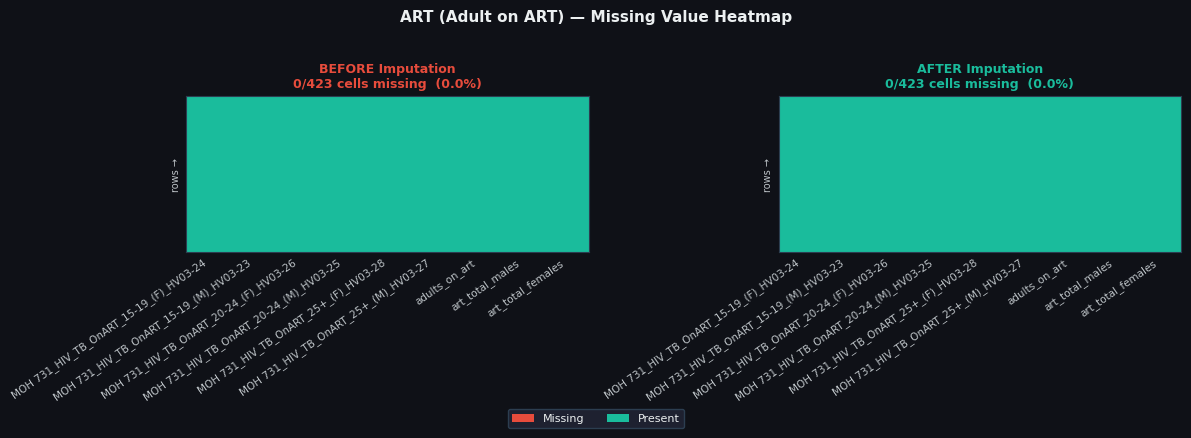

In [95]:
# id_cols excluded from heatmap — they are never missing by design
missing_heatmap(
    df_before = art_before,
    df_after  = art,
    label     = 'ART (Adult on ART)',
    id_cols   = [ART_COUNTY_COL, ART_PERIOD_COL, 'county', 'period'],
    figsize   = (12, 4),
)


### Cell 5 — Clean HTS

In [96]:
hts_raw = load_with_period(HTS_FILE, HTS_PERIOD_COL, 'HTS')
hts_raw = strip_suffix(hts_raw, HTS_COUNTY_COL, HTS_COUNTY_SUFFIX, 'HTS')
hts_raw = standardise(hts_raw, HTS_COUNTY_COL, 'HTS')
hts_raw = hts_raw.rename(columns=HTS_RENAME)

# Snapshot before imputation
hts_before = hts_raw.copy()

hts = to_numeric_impute(hts_raw.copy(), HTS_COUNTY_COL, HTS_PERIOD_COL)
hts = hts.rename(columns={HTS_COUNTY_COL: 'county', HTS_PERIOD_COL: 'period'})
validate(hts, 'HTS', period_col='period')
print()
print('HTS columns after cleaning:')
print(list(hts.columns))
hts.head(3)

  Loaded HTS: (47, 7)
  HTS: stripped suffix → 47 unique counties
  OK HTS: all county names standardised
  OK HTS: 47 counties (expected 47), 0 dups, 0 missing

HTS columns after cleaning:
['period', 'county', 'MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02', 'MOH 731_HTS_Tests _(M)_ HV01-01', 'hts_tested', 'hts_tested_males', 'hts_tested_females']


,period,county,MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02,MOH 731_HTS_Tests _(M)_ HV01-01,hts_tested,hts_tested_males,hts_tested_females
0,2025,Baringo,49731,11697,61428,11697,49731
1,2025,Bomet,82677,17389,100066,17389,82677
2,2025,Bungoma,197275,47767,245042,47767,197275


### Cell 6 — HTS: Before / After Missing Value Heatmap

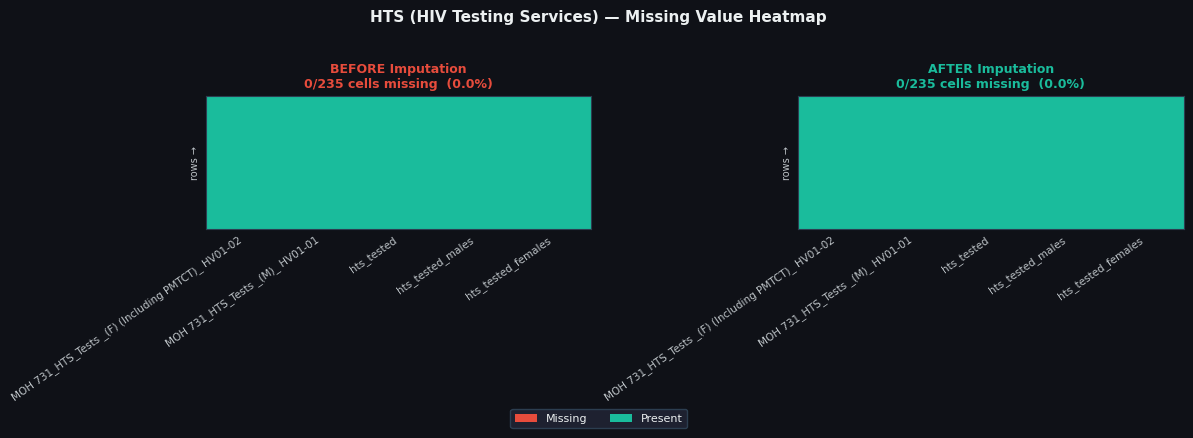

In [97]:
missing_heatmap(
    df_before = hts_before,
    df_after  = hts,
    label     = 'HTS (HIV Testing Services)',
    id_cols   = [HTS_COUNTY_COL, HTS_PERIOD_COL, 'county', 'period'],
    figsize   = (12, 4),
)


---
### Cell 6(b) — Clean HTS_Positive

> Same structure as HTS — Period + County + MOH age/sex cols + Total.  
> `hts_positive` (Total column) is the HIV positive test count per county.  
> Verah will use `hts_positive / hts_tested` to compute `hts_positivity_rate` in feature engineering.

In [98]:
hts_pos_raw = load_with_period(HTS_POSITIVE_FILE, HTS_POS_PERIOD_COL, 'HTS_Positive')
hts_pos_raw = strip_suffix(hts_pos_raw, HTS_POS_COUNTY_COL, HTS_POS_COUNTY_SUFFIX, 'HTS_Positive')
hts_pos_raw = standardise(hts_pos_raw, HTS_POS_COUNTY_COL, 'HTS_Positive')
hts_pos_raw = hts_pos_raw.rename(columns=HTS_POSITIVE_RENAME)
hts_pos_before = hts_pos_raw.copy()
hts_pos = to_numeric_impute(hts_pos_raw.copy(), HTS_POS_COUNTY_COL, HTS_POS_PERIOD_COL)
hts_pos = hts_pos.rename(columns={HTS_POS_COUNTY_COL: 'county', HTS_POS_PERIOD_COL: 'period'})
validate(hts_pos, 'HTS_Positive', period_col='period')
print()
print('HTS_Positive columns:', list(hts_pos.columns))
hts_pos.head(3)


  Loaded HTS_Positive: (47, 15)
  HTS_Positive: stripped suffix → 47 unique counties
  OK HTS_Positive: all county names standardised
  OK HTS_Positive: 47 counties (expected 47), 0 dups, 0 missing

HTS_Positive columns: ['period', 'county', 'MOH 731_HTS_Positive_2-9 _(M)_ HV01-06', 'MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07', 'MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09', 'MOH 731_HTS_Positive_10-14 _(M)_HV01-08', 'MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11', 'MOH 731_HTS_Positive_15-19 _(M)_HV01-10', 'MOH 731_HTS_Positive_20-24 _(M)_HV01-12', 'MOH 731_HTS_Positive_20-24 _(F) (Including PMTCT)_HV01-13', 'MOH 731_HTS_Positive_25+ _(M)_HV01-14', 'MOH 731_HTS_Positive_25+ _(F) (Including PMTCT)_HV01-15', 'hts_positive', 'hts_positive_males', 'hts_positive_females']


,period,county,MOH 731_HTS_Positive_2-9 _(M)_ HV01-06,MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07,MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09,MOH 731_HTS_Positive_10-14 _(M)_HV01-08,MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11,MOH 731_HTS_Positive_15-19 _(M)_HV01-10,MOH 731_HTS_Positive_20-24 _(M)_HV01-12,MOH 731_HTS_Positive_20-24 _(F) (Including PMTCT)_HV01-13,MOH 731_HTS_Positive_25+ _(M)_HV01-14,MOH 731_HTS_Positive_25+ _(F) (Including PMTCT)_HV01-15,hts_positive,hts_positive_males,hts_positive_females
0,2025,Baringo,5.0,4.0,2.0,2.0,6.0,6.0,6,37,128,200,390,141,249
1,2025,Bomet,16.0,27.0,6.0,5.0,56.0,8.0,20,145,400,508,1191,449,742
2,2025,Bungoma,57.0,47.0,28.0,21.0,107.0,9.0,48,376,739,1478,2910,874,2036


### Cell 6(c) — HTS_Positive: Before / After Missing Value Heatmap

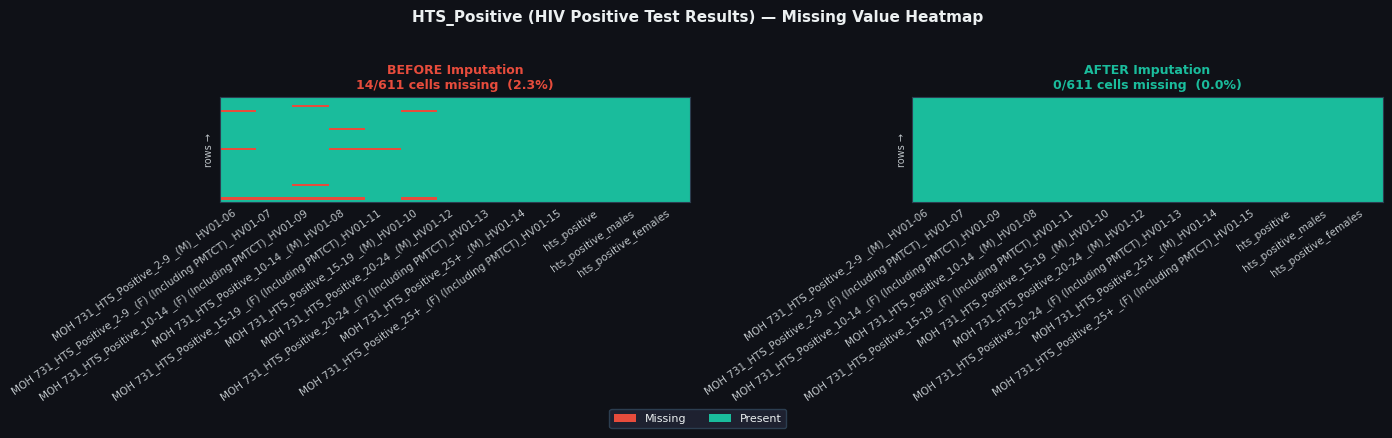

In [99]:
missing_heatmap(
    df_before = hts_pos_before,
    df_after  = hts_pos,
    label     = 'HTS_Positive (HIV Positive Test Results)',
    id_cols   = [HTS_POS_COUNTY_COL, HTS_POS_PERIOD_COL, 'county', 'period'],
    figsize   = (14, 4),
)


### Cell 7 — Clean VLT (no Period — snapshot join on county only)


- VLT has no Period column.
- In the merge step (notebook 03) VLT is joined to ART/HTS on county only,
- broadcasting the same VLT values across all periods for each county.


In [100]:
vlt_raw = load_snapshot(VLT_FILE, VLT_COUNTY_COL, 'VLT')
vlt_raw = standardise(vlt_raw, VLT_COUNTY_COL, 'VLT')
vlt_raw = vlt_raw.rename(columns=VLT_RENAME)
vlt_before = vlt_raw.copy()
vlt = to_numeric_impute(vlt_raw.copy(), VLT_COUNTY_COL)
vlt = vlt.rename(columns={VLT_COUNTY_COL: 'county'})

# Fix any NaN remaining after imputation
num_cols = vlt.select_dtypes(include='number').columns
for col in num_cols:
    vlt[col] = vlt[col].fillna(vlt[col].median())

validate(vlt, 'VLT')
print()
print('VLT columns:', list(vlt.columns))
vlt.head(3)


  Loaded VLT: (47, 7)
  OK VLT: all county names standardised
  OK VLT: 47 counties (expected 47), 0 dups, 0 missing

VLT columns: ['county', 'vlt_valid_under15', 'vls_suppressed_under15', 'vlt_valid_male_15plus', 'vls_suppressed_male_15plus', 'vlt_valid_female_15plus', 'vls_suppressed_female_15plus']


,county,vlt_valid_under15,vls_suppressed_under15,vlt_valid_male_15plus,vls_suppressed_male_15plus,vlt_valid_female_15plus,vls_suppressed_female_15plus
0,Baringo,73,56,807,743.0,1821,1701
1,Bomet,272,230,2276,2112.0,5230,4872
2,Bungoma,326,289,4039,3848.0,10589,10221


### Cell 7b — Engineer VLS Suppression Rates

The raw VLT file contains only **counts**. `vls_rate_adult` is required by the Care Gap Index in Notebook 04.

In [101]:
# ── Engineer VLS suppression rates from raw VLT counts ──────────────
# Uses column names from VLT_RENAME in constants.py
# vls_rate_adult is the primary Care Gap Index input (Notebook 04)

vlt['vls_rate_male15plus']   = (vlt['vls_suppressed_male_15plus']   / vlt['vlt_valid_male_15plus']).clip(0, 1).round(4)
vlt['vls_rate_female15plus'] = (vlt['vls_suppressed_female_15plus'] / vlt['vlt_valid_female_15plus']).clip(0, 1).round(4)
vlt['vls_rate_under15']      = (vlt['vls_suppressed_under15']       / vlt['vlt_valid_under15']).clip(0, 1).round(4)

total_valid      = vlt['vlt_valid_male_15plus']     + vlt['vlt_valid_female_15plus']
total_suppressed = vlt['vls_suppressed_male_15plus'] + vlt['vls_suppressed_female_15plus']
vlt['vls_rate_adult'] = (total_suppressed / total_valid).clip(0, 1).round(4)

print(f'National average VLS rate (adult 15+): {vlt["vls_rate_adult"].mean():.3f}')
print()
print(vlt[['county', 'vls_rate_adult']].sort_values('vls_rate_adult').head(5).to_string(index=False))
print()
for col in ['vls_rate_adult', 'vls_rate_male15plus', 'vls_rate_female15plus', 'vls_rate_under15']:
    bad = vlt[(vlt[col] < 0) | (vlt[col] > 1)]
    print(f'  {col}: {"OK" if len(bad) == 0 else f"WARNING {len(bad)} bad values"}')


National average VLS rate (adult 15+): 0.944

      county  vls_rate_adult
        Lamu          0.8136
  Tana River          0.8893
       Siaya          0.8947
      Isiolo          0.9017
Taita Taveta          0.9046

  vls_rate_adult: OK
  vls_rate_male15plus: OK
  vls_rate_female15plus: OK
  vls_rate_under15: OK


In [102]:
# Fix any NaN created during rate engineering
rate_cols = ['vls_rate_adult','vls_rate_male15plus',
             'vls_rate_female15plus','vls_rate_under15']
for col in rate_cols:
    vlt[col] = vlt[col].fillna(vlt[col].median())
print(f'VLT missing after fix: {vlt.isnull().sum().sum()}')

VLT missing after fix: 0


### Cell 8 — VLT: Before / After Missing Value Heatmap

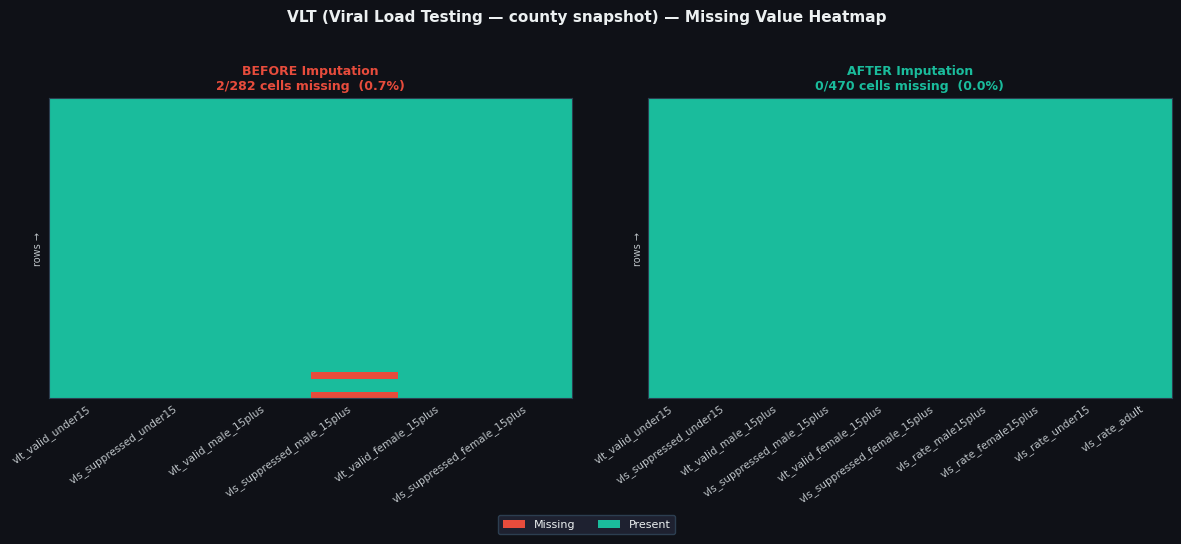

In [103]:
missing_heatmap(
    df_before = vlt_before,
    df_after  = vlt,
    label     = 'VLT (Viral Load Testing — county snapshot)',
    id_cols   = [VLT_COUNTY_COL, 'county'],
    figsize   = (12, 5),
)


### Cell 9 — Clean IIT (expand 9 regions → 47 counties)

In [104]:
iit_raw = load_iit(IIT_FILE, IIT_REGION_COL, 'IIT')

# Drop the Kenya national total row (IIT_REGION_MAP maps it to None)
iit_raw['_std_region'] = iit_raw[IIT_REGION_COL].map(IIT_REGION_MAP)
iit_raw = iit_raw[iit_raw['_std_region'].notna()].drop(columns=['_std_region'])

print(f'IIT after dropping national total: {iit_raw.shape}')
print(f'Regions: {list(iit_raw[IIT_REGION_COL].unique())}')

# Rename IIT columns to clean names
iit_raw = iit_raw.rename(columns=IIT_RENAME)

# Convert to numeric
data_cols = [c for c in iit_raw.columns if c != IIT_REGION_COL]
for col in data_cols:
    iit_raw[col] = pd.to_numeric(iit_raw[col], errors='coerce')

# Snapshot BEFORE expansion/imputation (region-level)
iit_before = iit_raw.copy()

print()
print('IIT columns after rename:')
print(list(iit_raw.columns))
iit_raw


  Loaded IIT: (9, 13)
IIT after dropping national total: (8, 13)
Regions: ['Rift Valley', 'Western', 'Eastern', 'Nyanza', 'Central', 'Coast', 'Nairobi', 'North Eastern']

IIT columns after rename:
['Region', 'Actively on Treatment by the Beginning of 2025 Children', 'iit_children', 'Actively on Treatment by the Beginning of 2025 female adult', 'iit_female', 'Actively on Treatment by the Beginning of 2025 Male', 'iit_male', 'adults_on_treatment', 'iit_count', 'iit_rate_pct', 'iit_rate_children_pct', 'iit_rate_male_pct', 'iit_rate_female_pct']


,Region,Actively on Treatment by the Beginning of 2025 Children,iit_children,Actively on Treatment by the Beginning of 2025 female adult,iit_female,Actively on Treatment by the Beginning of 2025 Male,iit_male,adults_on_treatment,iit_count,iit_rate_pct,iit_rate_children_pct,iit_rate_male_pct,iit_rate_female_pct
0,Rift Valley,474.0,62.0,7339.0,1125.0,3920.0,598.0,11259,1723,0.1530,0.131,0.153,0.153
1,Western,271.0,19.0,3730.0,341.0,1703.0,145.0,5433,486,0.0895,0.070,0.085,0.091
2,Eastern,241.0,17.0,3336.0,310.0,1745.0,141.0,5081,451,0.0888,0.071,0.081,0.093
3,Nyanza,607.0,52.0,9045.0,812.0,4415.0,417.0,13460,1229,0.0913,0.086,0.094,0.090
4,Central,142.0,12.0,2690.0,259.0,1422.0,155.0,4112,414,0.1007,0.085,0.109,0.096
5,Coast,161.0,26.0,2592.0,244.0,1199.0,107.0,3791,351,0.0926,0.161,0.089,0.094
6,Nairobi,169.0,18.0,4898.0,564.0,2494.0,271.0,7392,835,0.1130,0.107,0.109,0.115
7,North Eastern,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN


In [105]:
# Expand regions → counties
# Counts divided equally across counties in that region (approximation).
# Percentage columns (iit_rate_pct etc.) copied as-is — they apply region-wide.

rows = []
for _, row in iit_raw.iterrows():
    region     = row[IIT_REGION_COL]
    std_region = IIT_REGION_MAP.get(region)
    if not std_region or std_region not in REGION_TO_COUNTIES:
        print(f'  Skipping: {region}')
        continue
    counties = REGION_TO_COUNTIES[std_region]
    n = len(counties)
    for county in counties:
        new_row = {'county': county}
        for col in iit_raw.columns:
            if col == IIT_REGION_COL:
                continue
            val = row[col]
            try:
                fval = float(val)
                if 'pct' in col or 'rate' in col:
                    new_row[col] = fval          # percentage applies region-wide
                else:
                    new_row[col] = fval / n      # divide count equally
            except (ValueError, TypeError):
                new_row[col] = np.nan
        rows.append(new_row)

iit = pd.DataFrame(rows).reset_index(drop=True)
print(f'IIT expanded: {iit_raw.shape[0]} region rows → {iit.shape[0]} county rows')
validate(iit, 'IIT')
iit.head(5)


IIT expanded: 8 region rows → 47 county rows
  OK IIT: 47 counties (expected 47), 0 dups, 30 missing


,county,Actively on Treatment by the Beginning of 2025 Children,iit_children,Actively on Treatment by the Beginning of 2025 female adult,iit_female,Actively on Treatment by the Beginning of 2025 Male,iit_male,adults_on_treatment,iit_count,iit_rate_pct,iit_rate_children_pct,iit_rate_male_pct,iit_rate_female_pct
0,Turkana,33.857143,4.428571,524.214286,80.357143,280.0,42.714286,804.214286,123.071429,0.153,0.131,0.153,0.153
1,West Pokot,33.857143,4.428571,524.214286,80.357143,280.0,42.714286,804.214286,123.071429,0.153,0.131,0.153,0.153
2,Samburu,33.857143,4.428571,524.214286,80.357143,280.0,42.714286,804.214286,123.071429,0.153,0.131,0.153,0.153
3,Trans Nzoia,33.857143,4.428571,524.214286,80.357143,280.0,42.714286,804.214286,123.071429,0.153,0.131,0.153,0.153
4,Uasin Gishu,33.857143,4.428571,524.214286,80.357143,280.0,42.714286,804.214286,123.071429,0.153,0.131,0.153,0.153


In [106]:
rate_cols  = [c for c in iit.columns if 'pct' in c or 'rate' in c]
count_cols = [c for c in iit.columns if c not in rate_cols + ['county']]

for col in rate_cols:
    iit[col] = iit[col].fillna(iit[col].mean())
for col in count_cols:
    iit[col] = iit[col].fillna(0)

print(f'IIT missing after fix: {iit.isnull().sum().sum()}')

IIT missing after fix: 0


### Cell 10 — IIT: Before / After Missing Value Heatmap

**Before** = region-level raw (9 rows).  
**After** = county-level expanded (47 rows). Missing values show the effect of both imputation and the equal-share expansion.

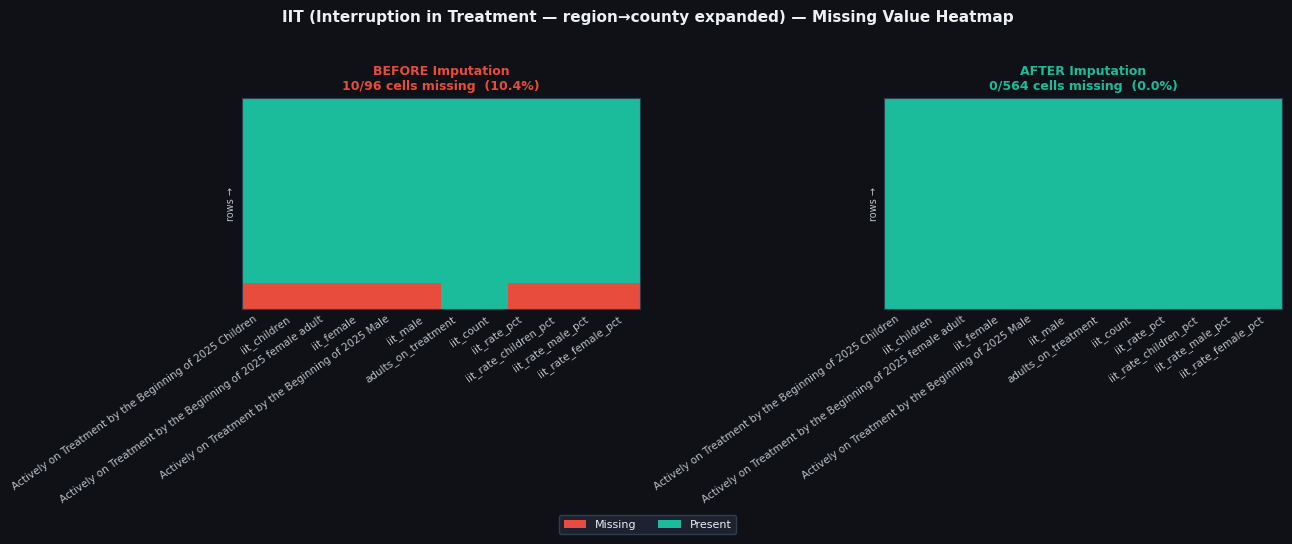

In [107]:
missing_heatmap(
    df_before = iit_before,
    df_after  = iit,
    label     = 'IIT (Interruption in Treatment — region→county expanded)',
    id_cols   = [IIT_REGION_COL, 'county'],
    figsize   = (13, 5),
)


### Cell 11 — Save all 4 NSDCC clean files

In [108]:
art.to_csv(ART_CLEAN,     index=False)
hts.to_csv(HTS_CLEAN,     index=False)
hts_pos.to_csv(HTS_POS_CLEAN, index=False)
vlt.to_csv(VLT_CLEAN,     index=False)
iit.to_csv(IIT_CLEAN,     index=False)

print(f'Saved -> {ART_CLEAN}')
print(f'Saved -> {HTS_CLEAN}')
print(f'Saved -> {HTS_POS_CLEAN}')
print(f'Saved -> {VLT_CLEAN}')
print(f'Saved -> {IIT_CLEAN}')

Saved -> c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\data\processed\adult_on_art_clean.csv
Saved -> c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\data\processed\hts_clean.csv
Saved -> c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\data\processed\hts_positive_clean.csv
Saved -> c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\data\processed\vlt_clean.csv
Saved -> c:\Users\HomePC\Documents\Phase-5-HIV-Care-Gap-AI\data\processed\iit_clean.csv


### Cell 12 — Final validation: reload and confirm

In [109]:
for label, path in [('ART',     ART_CLEAN),
                     ('HTS',     HTS_CLEAN),
                     ('HTS_POS', HTS_POS_CLEAN),
                     ('VLT',     VLT_CLEAN),
                     ('IIT',     IIT_CLEAN)]:
    df = pd.read_csv(path)
    n_counties = df['county'].nunique()
    n_missing  = df.isnull().sum().sum()
    status = 'OK' if n_counties == 47 and n_missing == 0 else 'WARNING'
    print(f'  {status} {label:<8} {df.shape[0]:>3} rows x {df.shape[1]:>3} cols  '
          f'| counties: {n_counties}  | missing: {n_missing}')


  OK ART       47 rows x  11 cols  | counties: 47  | missing: 0
  OK HTS       47 rows x   7 cols  | counties: 47  | missing: 0
  OK HTS_POS   47 rows x  15 cols  | counties: 47  | missing: 0
  OK VLT       47 rows x  11 cols  | counties: 47  | missing: 0
  OK IIT       47 rows x  13 cols  | counties: 47  | missing: 0


In [110]:
from src.nsdcc_cleaner import validate

print("Module imported successfully")

Module imported successfully


---
### Git commit
```bash
git add notebooks/02_nsdcc_cleaning.ipynb
git add src/nsdcc_cleaner.py
git add data/processed/adult_on_art_clean.csv
git add data/processed/hts_clean.csv
git add data/processed/hts_positive_clean.csv
git add data/processed/vlt_clean.csv
git add data/processed/iit_clean.csv
git commit -m "feat(data): clean 5 NSDCC files; validate 47 counties, 0 missing

- ART/HTS/HTS_Positive: stripped County suffix, standardised names,
  renamed MOH cols using constants.py rename maps
- VLT: standardised mixed county naming, imputed 2 missing values
- IIT: dropped national total row, expanded 8 regions to 47 counties,
  fixed North Eastern NaN after expansion
- Before/after dark-themed missing-value heatmaps for all 5 datasets
- All 5 files validated: 47 counties, 0 duplicates, 0 missing
- Saved to data/processed/ via constants.py paths
- Added src/nsdcc_cleaner.py with reusable cleaning functions
